Dataset shape: (22750, 9)


First 5 rows:


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52



Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB

Statistical summary:


,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,21369.000000,20633.000000,21626.000000
mean,2.178725,4.481398,5.728188,0.452005
std,1.135145,2.047211,1.920839,0.198226
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.310000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000



Missing values per column:
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

Burn Rate distribution:
count    21626.000000
mean         0.452005
std          0.198226
min          0.000000
25%          0.310000
50%          0.450000
75%          0.590000
max          1.000000
Name: Burn Rate, dtype: float64


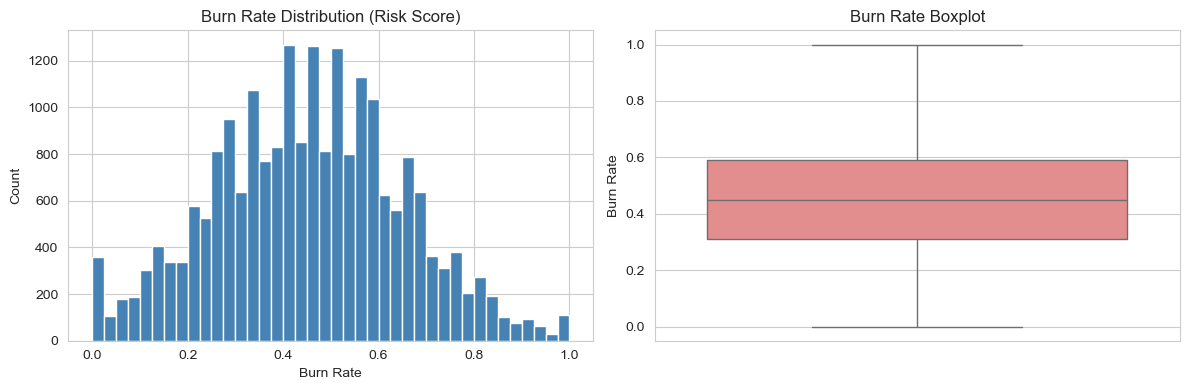


Gender:
Gender
Female    11908
Male      10842
Name: count, dtype: int64

Company Type:
Company Type
Service    14833
Product     7917
Name: count, dtype: int64

WFH Setup Available:
WFH Setup Available
Yes    12290
No     10460
Name: count, dtype: int64

Designation:
Designation
2.0    7588
3.0    5985
1.0    4881
4.0    2391
0.0    1507
5.0     398
Name: count, dtype: int64


In [1]:
# ============================================
# STEP 1: SETUP & DATA EXPLORATION
# AI-Based Personnel Stress & Welfare Monitoring
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# ---------- 1. Load the dataset ----------
# Make sure train.csv is in the same folder as your notebook
df = pd.read_csv('train.csv')

print("Dataset shape:", df.shape)
print("\n" + "="*50)

# ---------- 2. First look ----------
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn info:")
df.info()

# ---------- 3. Statistical summary ----------
print("\nStatistical summary:")
display(df.describe())

# ---------- 4. Missing values check ----------
# CRITICAL: Missing Mental Fatigue Score matters — it's a key wellness signal
print("\nMissing values per column:")
print(df.isnull().sum())

# ---------- 5. Target variable distribution ----------
print("\nBurn Rate distribution:")
print(df['Burn Rate'].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Burn Rate'].dropna(), bins=40, color='steelblue', edgecolor='white')
plt.title('Burn Rate Distribution (Risk Score)')
plt.xlabel('Burn Rate')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Burn Rate'], color='lightcoral')
plt.title('Burn Rate Boxplot')

plt.tight_layout()
plt.show()

# ---------- 6. Categorical features overview ----------
for col in ['Gender', 'Company Type', 'WFH Setup Available', 'Designation']:
    print(f"\n{col}:")
    print(df[col].value_counts())

Dropped 1124 rows with missing Burn Rate. Remaining: 21626

Missing values after imputation:
Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
Tenure_Years            0
dtype: int64

Risk category distribution:
risk_category
MODERATE    10746
LOW          5726
HIGH         5154
Name: count, dtype: int64

As percentages:
risk_category
MODERATE    49.7
LOW         26.5
HIGH        23.8
Name: proportion, dtype: float64


C:\Users\Bikram\AppData\Local\Temp\ipykernel_14016\465905749.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='risk_category',


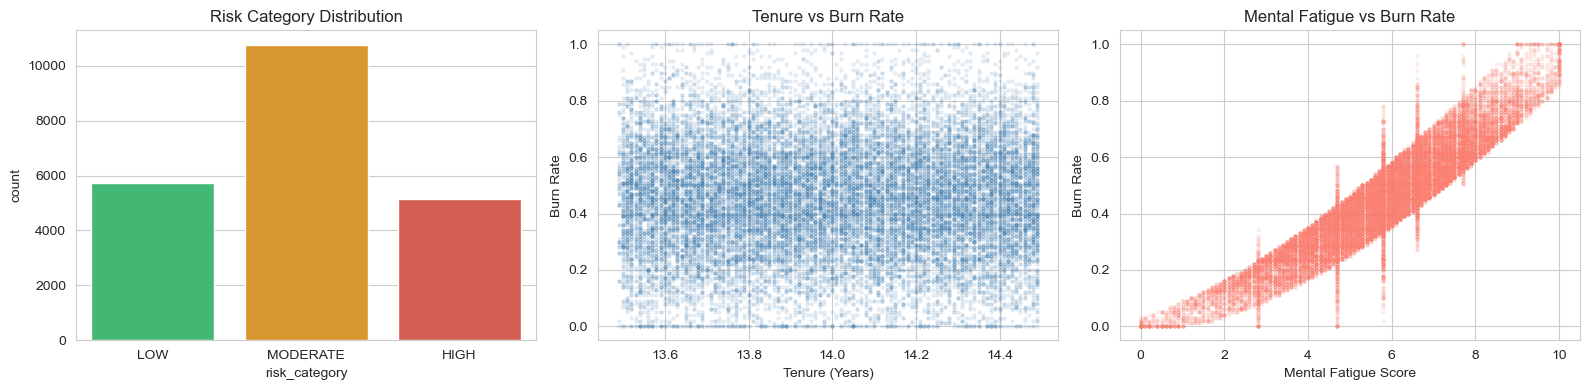


Cleaned data saved to 'cleaned_data.csv'
Final shape: (21626, 12)


In [2]:
# ============================================
# STEP 2: CLEANING & FEATURE ENGINEERING
# ============================================

df_clean = df.copy()

# ---------- 1. Drop rows with missing target ----------
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Burn Rate'])
print(f"Dropped {before - len(df_clean)} rows with missing Burn Rate. Remaining: {len(df_clean)}")

# ---------- 2. Create Tenure feature from Date of Joining ----------
df_clean['Date of Joining'] = pd.to_datetime(df_clean['Date of Joining'])

# Use a fixed reference date for reproducibility (dataset is from ~2022)
# In the deployed system, this would be "today's date" for live tenure.
REFERENCE_DATE = pd.Timestamp('2022-06-30')
df_clean['Tenure_Years'] = (
    (REFERENCE_DATE - df_clean['Date of Joining']).dt.days / 365.25
).round(2)

# ---------- 3. Group-wise median imputation ----------
# Impute missing values using median of same Designation group
for col in ['Resource Allocation', 'Mental Fatigue Score']:
    df_clean[col] = df_clean.groupby('Designation')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Sanity check — imputation should be complete now
print("\nMissing values after imputation:")
print(df_clean.isnull().sum())

# Flag imputed rows (transparency — track which rows had estimated wellness data)
# In the real system, imputed/estimated features feed into a "confidence" note
df_clean['Fatigue_Was_Imputed'] = df['Mental Fatigue Score'].isnull().astype(int)

# ---------- 4. Rename columns to deployment-friendly names ----------
# These names match what the FastAPI endpoint will eventually expect as JSON keys
df_clean = df_clean.rename(columns={
    'Gender': 'gender',
    'Company Type': 'company_type',
    'WFH Setup Available': 'wfh_setup',
    'Designation': 'designation',
    'Resource Allocation': 'resource_allocation',
    'Mental Fatigue Score': 'mental_fatigue_score',
    'Burn Rate': 'burn_rate',
})

# ---------- 5. Create risk categories ----------
# Quartile-aligned thresholds: LOW / MODERATE / HIGH
def assign_risk(burn_rate):
    if burn_rate < 0.33:
        return 'LOW'
    elif burn_rate < 0.60:
        return 'MODERATE'
    else:
        return 'HIGH'

df_clean['risk_category'] = df_clean['burn_rate'].apply(assign_risk)

print("\nRisk category distribution:")
print(df_clean['risk_category'].value_counts())
print("\nAs percentages:")
print(df_clean['risk_category'].value_counts(normalize=True).round(3) * 100)

# ---------- 6. Visualize ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Risk distribution
sns.countplot(data=df_clean, x='risk_category',
              order=['LOW', 'MODERATE', 'HIGH'],
              palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('Risk Category Distribution')

# Tenure vs Burn Rate
axes[1].scatter(df_clean['Tenure_Years'], df_clean['burn_rate'],
                alpha=0.1, s=5, color='steelblue')
axes[1].set_title('Tenure vs Burn Rate')
axes[1].set_xlabel('Tenure (Years)')
axes[1].set_ylabel('Burn Rate')

# Fatigue vs Burn Rate
axes[2].scatter(df_clean['mental_fatigue_score'], df_clean['burn_rate'],
                alpha=0.1, s=5, color='salmon')
axes[2].set_title('Mental Fatigue vs Burn Rate')
axes[2].set_xlabel('Mental Fatigue Score')
axes[2].set_ylabel('Burn Rate')

plt.tight_layout()
plt.show()

# ---------- 7. Save cleaned data ----------
df_clean.to_csv('cleaned_data.csv', index=False)
print("\nCleaned data saved to 'cleaned_data.csv'")
print("Final shape:", df_clean.shape)

Feature columns for the model:
['designation', 'resource_allocation', 'mental_fatigue_score', 'Tenure_Years', 'Fatigue_Was_Imputed', 'gender_Female', 'gender_Male', 'company_type_Product', 'company_type_Service', 'wfh_setup_No', 'wfh_setup_Yes']

Feature matrix shape: (21626, 11)

Train set: 17300 rows | Test set: 4326 rows

Risk distribution in test set (should mirror overall ~24/50/26):
risk_category
MODERATE    49.7
LOW         26.5
HIGH        23.8
Name: proportion, dtype: float64
[0]	validation_0-rmse:0.18925	validation_1-rmse:0.19087
[100]	validation_0-rmse:0.05719	validation_1-rmse:0.06001
[200]	validation_0-rmse:0.05536	validation_1-rmse:0.05985
[218]	validation_0-rmse:0.05513	validation_1-rmse:0.05989

Best iteration: 169

--- Regression Metrics (Risk Score) ---
MAE : 0.0471
RMSE: 0.0598
R²  : 0.9102

--- Classification Report (Risk Category) ---
              precision    recall  f1-score   support

         LOW       0.90      0.83      0.86      1145
    MODERATE       0.82

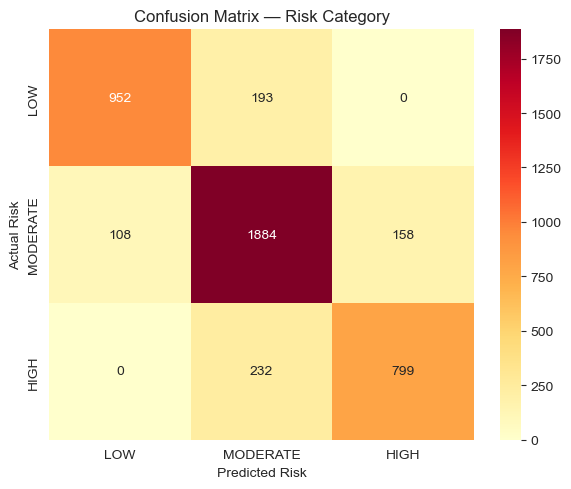

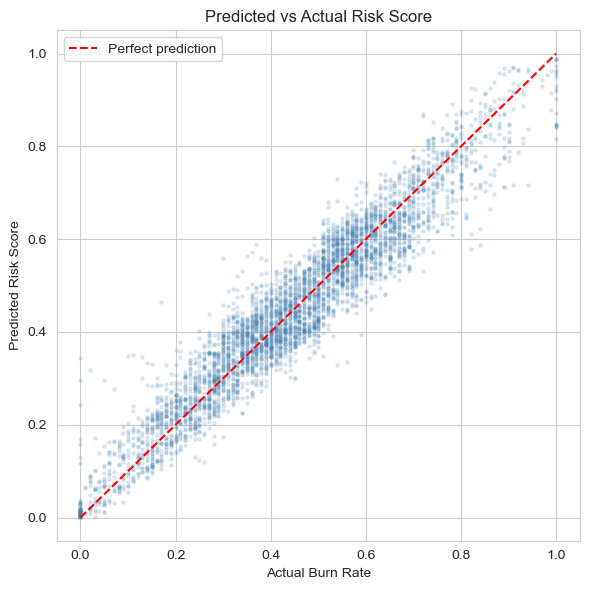


Model and feature names saved (needed for the FastAPI step later).


In [3]:
# ============================================
# STEP 3: ENCODING, SPLIT & XGBOOST TRAINING
# ============================================

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix)

# ---------- 1. Prepare feature matrix ----------
# Drop identifiers and the raw target/label from features
drop_cols = ['Employee ID', 'Date of Joining', 'burn_rate', 'risk_category']
X = df_clean.drop(columns=drop_cols)
y_score = df_clean['burn_rate'].copy()          # regression target
y_category = df_clean['risk_category'].copy()   # for stratification & eval only

# One-hot encode low-cardinality categoricals
X = pd.get_dummies(X, columns=['gender', 'company_type', 'wfh_setup'],
                   drop_first=False, dtype=int)

print("Feature columns for the model:")
print(list(X.columns))
print("\nFeature matrix shape:", X.shape)

# ---------- 2. Stratified train/test split ----------
# Stratify on the risk category so HIGH/MODERATE/LOW proportions match in both sets
X_train, X_test, y_train, y_test, cat_train, cat_test = train_test_split(
    X, y_score, y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print(f"\nTrain set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print("\nRisk distribution in test set (should mirror overall ~24/50/26):")
print(cat_test.value_counts(normalize=True).round(3) * 100)

# ---------- 3. Train XGBoost regressor with early stopping ----------
model = xgb.XGBRegressor(
    n_estimators=1000,        # max trees; early stopping will find the right number
    learning_rate=0.05,       # small lr + more trees = smoother fit
    max_depth=6,
    min_child_weight=5,       # conservative: prevents overfitting to tiny groups
    subsample=0.8,            # row sampling -> reduces variance
    colsample_bytree=0.8,     # column sampling -> reduces feature over-reliance
    reg_lambda=1.5,           # L2 regularization
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print(f"\nBest iteration: {model.best_iteration}")

# ---------- 4. Evaluate as a RISK SCORE (regression metrics) ----------
y_pred_score = model.predict(X_test)
y_pred_score = np.clip(y_pred_score, 0, 1)  # scores must stay in valid [0,1] range

print("\n--- Regression Metrics (Risk Score) ---")
print(f"MAE : {mean_absolute_error(y_test, y_pred_score):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_score)):.4f}")
print(f"R²  : {r2_score(y_test, y_pred_score):.4f}")

# ---------- 5. Evaluate as a RISK CATEGORY (what welfare officers see) ----------
def assign_risk(v):
    if v < 0.33:
        return 'LOW'
    elif v < 0.60:
        return 'MODERATE'
    else:
        return 'HIGH'

y_pred_cat = pd.Series(y_pred_score).apply(assign_risk)

print("\n--- Classification Report (Risk Category) ---")
print(classification_report(cat_test, y_pred_cat,
                            labels=['LOW', 'MODERATE', 'HIGH']))

# Confusion matrix — CRITICAL for the ethics narrative
cm = confusion_matrix(cat_test, y_pred_cat, labels=['LOW', 'MODERATE', 'HIGH'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['LOW', 'MODERATE', 'HIGH'],
            yticklabels=['LOW', 'MODERATE', 'HIGH'])
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.title('Confusion Matrix — Risk Category')
plt.tight_layout()
plt.show()

# ---------- 6. Prediction vs actual scatter ----------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_score, alpha=0.15, s=5, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual Burn Rate')
plt.ylabel('Predicted Risk Score')
plt.title('Predicted vs Actual Risk Score')
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 7. Save the trained model ----------
import joblib
joblib.dump(model, 'stress_model.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')
print("\nModel and feature names saved (needed for the FastAPI step later).")

SHAP values computed. Shape: (4326, 11)


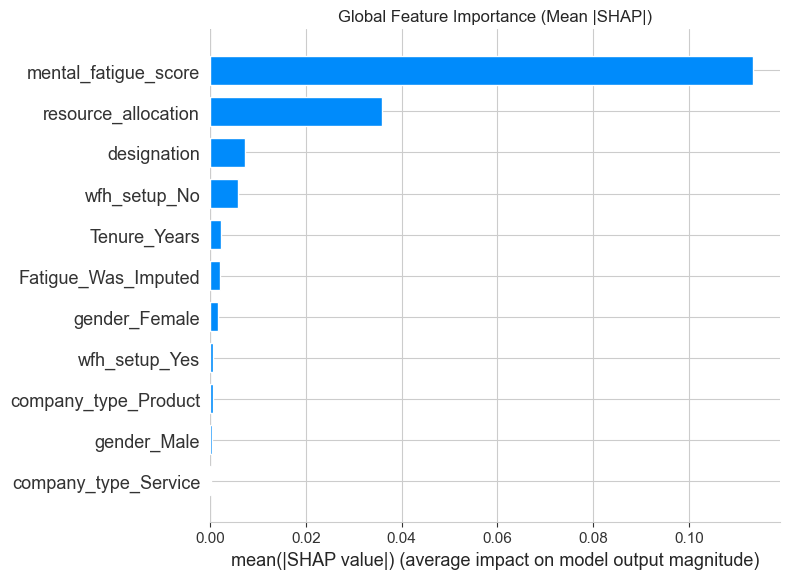

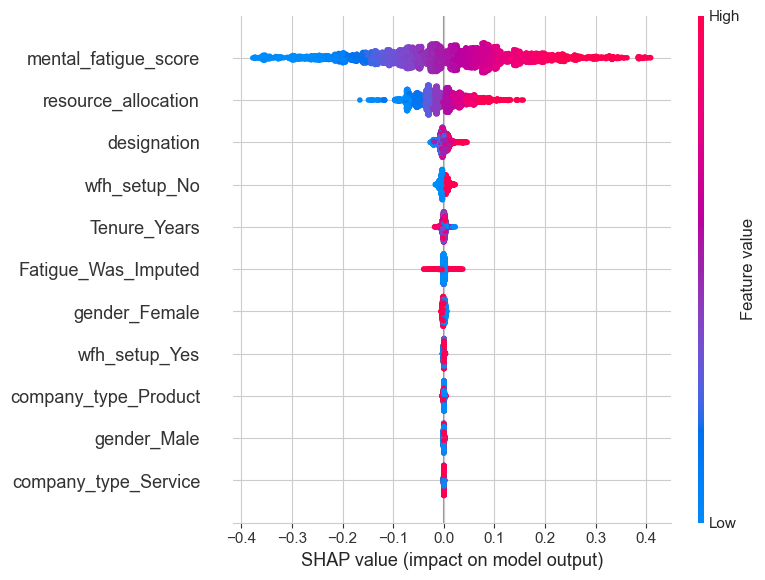

Explaining prediction for test case (actual risk: HIGH)
Predicted risk score: 0.648

Feature values for this person:


,designation,resource_allocation,mental_fatigue_score,Tenure_Years,Fatigue_Was_Imputed,gender_Female,gender_Male,company_type_Product,company_type_Service,wfh_setup_No,wfh_setup_Yes
956,3.0,7.0,7.5,14.17,0,0,1,1,0,0,1


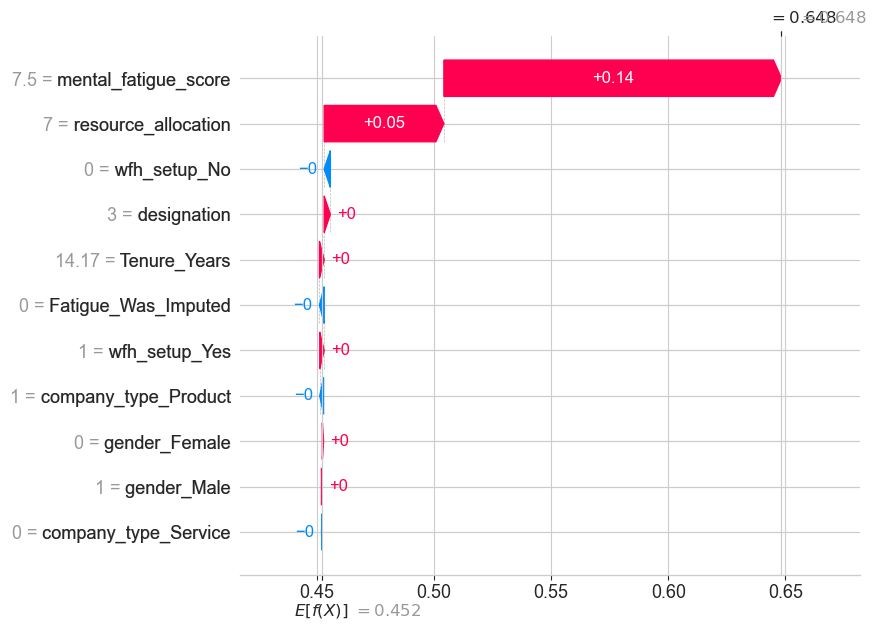


Explaining prediction for test case (actual risk: LOW)
Predicted risk score: 0.274


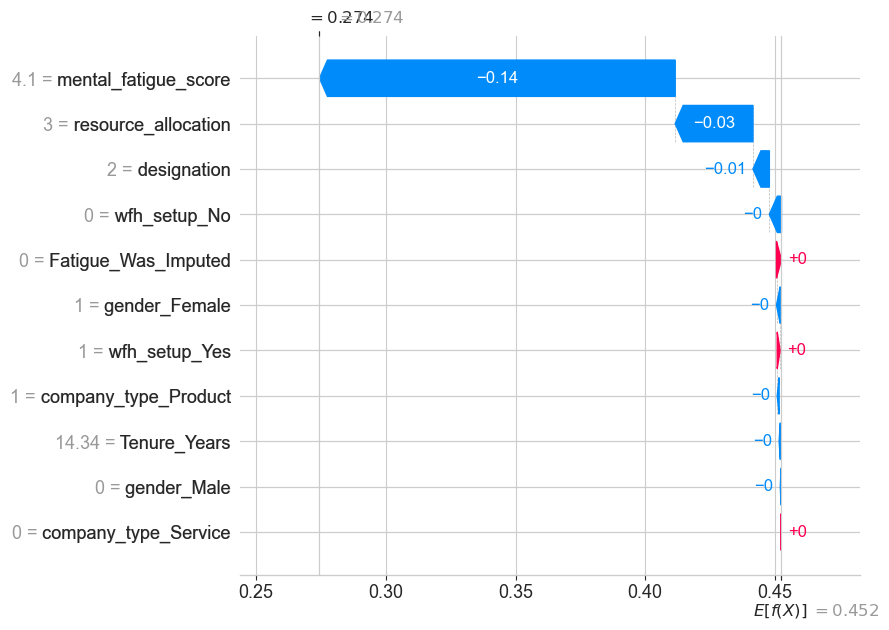


SHAP explainer saved — we'll load this in the API step.


In [4]:
# ============================================
# STEP 4: SHAP EXPLAINABILITY
# ============================================

import shap
import joblib

# ---------- 1. Create the SHAP explainer ----------
# TreeExplainer is the fast, exact algorithm for tree models like XGBoost
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set (can take ~30-60 seconds)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed. Shape:", shap_values.shape)

# ---------- 2. GLOBAL view: which features drive risk across the force ----------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (Mean |SHAP|)")
plt.tight_layout()
plt.show()

# ---------- 3. Beeswarm: importance AND direction of effect ----------
# Each dot = one person. Red = high feature value, blue = low.
# X-axis = impact on risk score (right = pushes risk UP)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# ---------- 4. INDIVIDUAL view: explain ONE prediction (a HIGH-risk case) ----------
# Find an actual HIGH-risk person in the test set
high_idx = cat_test[cat_test == 'HIGH'].index[0]
high_pos = list(X_test.index).index(high_idx)

print(f"Explaining prediction for test case (actual risk: {cat_test.loc[high_idx]})")
print(f"Predicted risk score: {y_pred_score[high_pos]:.3f}")
print("\nFeature values for this person:")
display(X_test.loc[[high_idx]])

# Waterfall: shows how the model got from the base (average) score to THIS score
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_pos]
    ),
    max_display=11
)

# ---------- 5. For contrast: a LOW-risk case ----------
low_idx = cat_test[cat_test == 'LOW'].index[0]
low_pos = list(X_test.index).index(low_idx)

print(f"\nExplaining prediction for test case (actual risk: {cat_test.loc[low_idx]})")
print(f"Predicted risk score: {y_pred_score[low_pos]:.3f}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_pos]
    ),
    max_display=11
)

# ---------- 6. Save the explainer for the FastAPI endpoint ----------
joblib.dump(explainer, 'shap_explainer.pkl')
print("\nSHAP explainer saved — we'll load this in the API step.")